# Bank Marketing - Modeling

**DATA 4950 Week 13 Demo**

## What We Will Cover


1. Load preprocessed data
2. All models — default parameters (Simple Train/Test)
3. Cross-validation
4. Hyperparameter tuning (GridSearchCV)
5. Final model comparision
6. Save the best model

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SMOTE
X_train_smote = pd.read_csv('../data/modeling/X_train_smote.csv')
y_train_smote = pd.read_csv('../data/modeling/y_train_smote.csv').squeeze()

print(f'Training (original): {X_train.shape}')
print(f'Training (SMOTE):    {X_train_smote.shape}')
print(f'Test:                {X_test.shape}')
print(f'\nClass distribution (train): {y_train.value_counts().to_dict()}')
print(f'Class distribution (test):  {y_test.value_counts().to_dict()}')

Training (original): (32940, 51)
Training (SMOTE):    (58458, 51)
Test:                (8236, 51)

Class distribution (train): {0: 29229, 1: 3711}
Class distribution (test):  {0: 7308, 1: 928}


## PART 1: Basic Models

Start simple. Build complexity gradually.

Train and Test ROC-AUC are printed side by side for every model — a gap > 0.05 suggests overfitting

### model 1: logistic regression

In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=4950)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=4950)

In [4]:
y_pred = lr.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [5]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [6]:
y_prob = lr.predict_proba(X_test)[:, 1]   # probability of class 1 (yes)
y_prob[:50]

array([0.04373112, 0.06082673, 0.40301314, 0.0763816 , 0.05513284,
       0.08439152, 0.04800025, 0.03840082, 0.03583804, 0.03999497,
       0.05799747, 0.10436918, 0.13806305, 0.08249647, 0.07950373,
       0.031863  , 0.09746784, 0.05779939, 0.03703271, 0.08061178,
       0.07141533, 0.10428982, 0.03563796, 0.05861716, 0.2124909 ,
       0.06736282, 0.05722181, 0.04409246, 0.03537759, 0.03017704,
       0.26035937, 0.0367174 , 0.07660427, 0.36298828, 0.04864224,
       0.03942407, 0.04539388, 0.07003898, 0.02996168, 0.05246319,
       0.0422043 , 0.03968505, 0.21086091, 0.09288276, 0.06901408,
       0.11542954, 0.06253316, 0.02220946, 0.05201688, 0.05011197])

In [7]:
## train metrics — to check for overfitting
y_train_pred = lr.predict(X_train)
y_train_prob = lr.predict_proba(X_train)[:, 1]

In [8]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

In [9]:
auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.7932  |  Test: 0.7964  |  Gap: -0.0032


In [10]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.67      0.22      0.33       928

    accuracy                           0.90      8236
   macro avg       0.79      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236



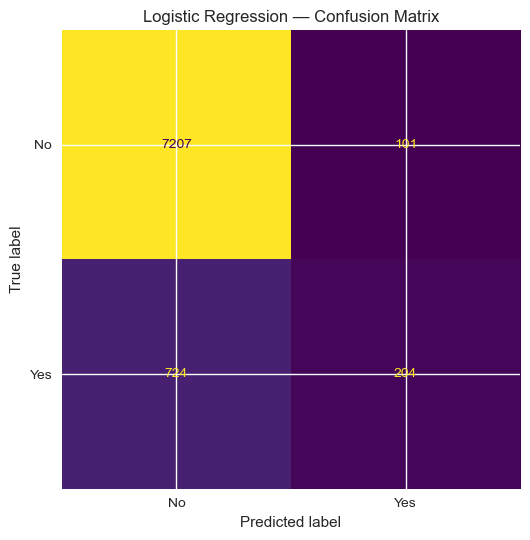

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No','Yes'], colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
results = []

report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Logistic Regression',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8998300145701797,
  'Precision (Yes)': 0.6688524590163935,
  'Recall (Yes)': 0.21982758620689655,
  'F1 (Yes)': 0.3309002433090024,
  'ROC-AUC': 0.7964427416577015,
  'ROC-AUC Train': 0.7932233041091744}]

In [13]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932


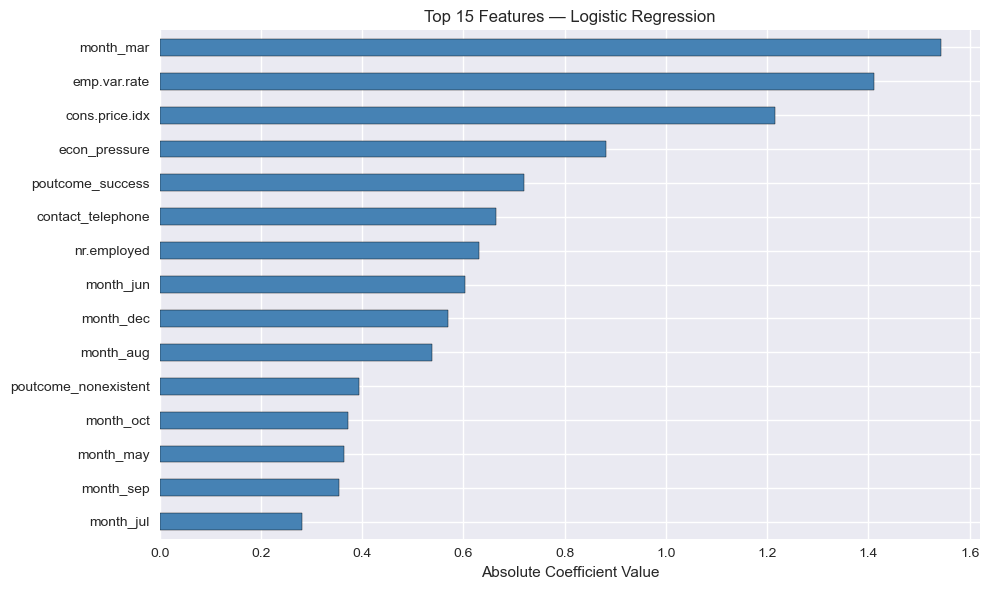

In [14]:
importances = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 15 Features — Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:**

- Train AUC vs Test AUC gap: 0.0032, no overfitting.
- Recall (Yes):  0.2198. The model only identifies 22% of real depositors at the default 0.5 threshold. This is the class imbalance problem, the model predicts 88% 'No' data during training and learns that 'No' is almost always right. This is not a model failure; it is a data distribution problem.
- Precision (Yes): 0.6689. When the model does predict 'Yes', it is correct 67% of the time. High precision but low recall is the classic signature of an imbalanced-data model.
- Accuracy = 0.90. Misleading — a 'predict No always' baseline scores 88%. Never cite accuracy as evidence of quality on this dataset.

### model 2: SVM 

Use **scaled** data. `SVC(probability=True)` enables `.predict_proba()` for ROC-AUC.
SVM is evaluated with default parameters only — no GridSearchCV (too slow on large datasets).

In [15]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=4950)
svm.fit(X_train, y_train)

SVC(probability=True, random_state=4950)

In [16]:
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

y_train_pred = svm.predict(X_train)
y_train_prob = svm.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.8783  |  Test: 0.6930  |  Gap: 0.1853


In [17]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.68      0.25      0.36       928

    accuracy                           0.90      8236
   macro avg       0.80      0.62      0.65      8236
weighted avg       0.89      0.90      0.88      8236



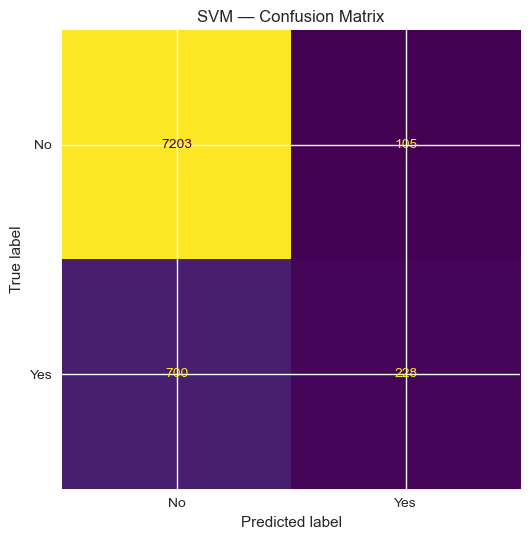

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [19]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'SVM',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8998300145701797,
  'Precision (Yes)': 0.6688524590163935,
  'Recall (Yes)': 0.21982758620689655,
  'F1 (Yes)': 0.3309002433090024,
  'ROC-AUC': 0.7964427416577015,
  'ROC-AUC Train': 0.7932233041091744},
 {'Model': 'SVM',
  'Accuracy': 0.9022583778533269,
  'Precision (Yes)': 0.6846846846846847,
  'Recall (Yes)': 0.24568965517241378,
  'F1 (Yes)': 0.36161776367961934,
  'ROC-AUC': 0.6930305917700017,
  'ROC-AUC Train': 0.8783083182642561}]

In [20]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783


How does SVM compare to Logistic Regression given both use scaled data? 

Train AUC ≈ 0.878, Test AUC ≈ 0.693 (gap ≈ 0.185). SVM achieves higher accuracy and precision, but is overfitting on the training data

### model 3: decision tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier( random_state=4950)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=4950)

In [22]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

y_train_pred = dt.predict(X_train)
y_train_prob = dt.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.9999  |  Test: 0.6371  |  Gap: 0.3628


In [23]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.92      0.91      0.91      7308
         Yes       0.33      0.36      0.34       928

    accuracy                           0.84      8236
   macro avg       0.62      0.63      0.63      8236
weighted avg       0.85      0.84      0.85      8236



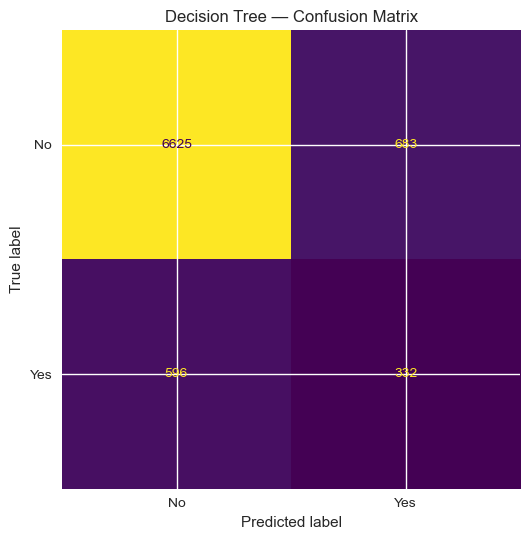

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [25]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Decision Tree',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8998300145701797,
  'Precision (Yes)': 0.6688524590163935,
  'Recall (Yes)': 0.21982758620689655,
  'F1 (Yes)': 0.3309002433090024,
  'ROC-AUC': 0.7964427416577015,
  'ROC-AUC Train': 0.7932233041091744},
 {'Model': 'SVM',
  'Accuracy': 0.9022583778533269,
  'Precision (Yes)': 0.6846846846846847,
  'Recall (Yes)': 0.24568965517241378,
  'F1 (Yes)': 0.36161776367961934,
  'ROC-AUC': 0.6930305917700017,
  'ROC-AUC Train': 0.8783083182642561},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8447061680427392,
  'Precision (Yes)': 0.3270935960591133,
  'Recall (Yes)': 0.3577586206896552,
  'F1 (Yes)': 0.34173957797220794,
  'ROC-AUC': 0.6370649695421172,
  'ROC-AUC Train': 0.9998831922379463}]

In [26]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999


Train AUC=0.9999, near 1.0: the models memorize the training data perfectly. 

### model 4: random forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)  ##An ensemble of 100 independent decision trees.
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=4950)

In [28]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

y_train_pred = rf.predict(X_train)
y_train_prob = rf.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.9998  |  Test: 0.7824  |  Gap: 0.2174


In [29]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.92      0.97      0.94      7308
         Yes       0.53      0.31      0.39       928

    accuracy                           0.89      8236
   macro avg       0.72      0.64      0.67      8236
weighted avg       0.87      0.89      0.88      8236



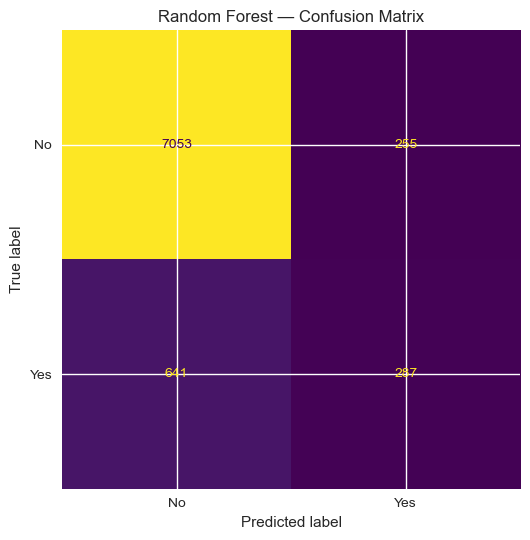

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [31]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Random Forest',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})


In [32]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998


How does ensemble performance compare to the single tree?

- Random Forest test AUC (0.782) >> Decision Tree (0.637). The ensemble of 100 trees dramatically outperforms a single tree by averaging out individual overfitting.
- Both show severe overfitting: RF gap = 0.217, DT gap = 0.363. GridSearchCV with `max_depth` constraints will address this.

### model 5: gradient boosting 

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=4950)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=4950)

In [34]:
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

y_train_pred = gb.predict(X_train)
y_train_prob = gb.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_train_prob)
auc_test = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')

ROC-AUC  Train: 0.8088  |  Test: 0.8038  |  Gap: 0.0050


In [35]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.68      0.24      0.36       928

    accuracy                           0.90      8236
   macro avg       0.80      0.61      0.65      8236
weighted avg       0.89      0.90      0.88      8236



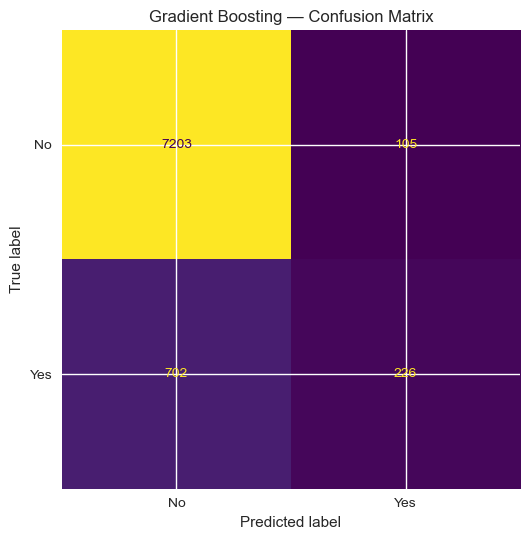

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['No', 'Yes'],
                                        colorbar=False)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

In [37]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Gradient Boosting',
    'Accuracy'       : report['accuracy'],
    'Precision (Yes)': report['Yes']['precision'],
    'Recall (Yes)'   : report['Yes']['recall'],
    'F1 (Yes)'       : report['Yes']['f1-score'],
    'ROC-AUC'        : auc_test,
    'ROC-AUC Train'  : auc_train,
})

In [38]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998
4,Gradient Boosting,0.9020,0.6828,0.2435,0.3590,0.8038,0.8088


Is Gradient Boosting better or worse than Random Forest?

- Gradient Boosting wins on AUC: 0.804 vs 0.782, a 0.022 difference. But is this real or a lucky split? Cross-validation will answer this.
- Gradient Boosting shows no overfitting:  Train AUC = 0.809 ≈ Test AUC = 0.804 (gap = 0.005). This is the healthiest result so far — the model generalizes well without constraints.

### Quick comparision

**Observations:**

- Best default model:  gradient boost because we have the best ROC-AUC=0.8038 with no overfitting
- Models with overfitting (Train/Test gap > 0.05): SVM, Decision Tree, Random Forest
- Overall: is accuracy a reliable metric here? Why or why not?  Accuracy is not a reliable metric when we have imbalanced data. All models score 84–90% accuracy, but a 'predict No always' baseline scores 88%. Accuracy is inflated by the majority class and says nothing about depositor detection. Use ROC-AUC and Recall (Yes) instead.

## Does SMOTE Help?

 we trained Section 2 models on original data
 
 now retrain the same models on SMOTE data and compare
 
test set stays the same — only training data changes

In [39]:
## retrain all five models on SMOTE data

lr_s = LogisticRegression(max_iter=1000, random_state=4950)
dt_s = DecisionTreeClassifier(random_state=4950)
svm_s = SVC(probability=True, random_state=4950)
rf_s = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)
gb_s = GradientBoostingClassifier(random_state=4950)

lr_s.fit(X_train_smote, y_train_smote)
dt_s.fit(X_train_smote, y_train_smote)
svm_s.fit(X_train_smote, y_train_smote)
rf_s.fit(X_train_smote, y_train_smote)
gb_s.fit(X_train_smote, y_train_smote)

print('Retrained on SMOTE data.')

Retrained on SMOTE data.


In [40]:
## collect AUC for both versions

result_smote = {}
for name, orig, smote in [('Logistic Regression', lr, lr_s),
                           ('Decision Tree',       dt, dt_s),
                           ('SVM',       svm, svm_s),
                           ('Random Forest',       rf, rf_s),
                           ('Gradient Boosting',       gb, gb_s)]:

    auc_orig  = roc_auc_score(y_test, orig.predict_proba(X_test)[:, 1])
    auc_smote = roc_auc_score(y_test, smote.predict_proba(X_test)[:, 1])
    result_smote[name] = {'Original': round(auc_orig, 4),
                     'SMOTE':    round(auc_smote, 4),
                     'Gain':     round(auc_smote - auc_orig, 4)}

smote_comparison = pd.DataFrame(result_smote).T.reset_index()
smote_comparison.columns = ['Model', 'Original AUC', 'SMOTE AUC', 'Gain']

print('SMOTE vs Original — ROC-AUC on Test Set:')
print(smote_comparison)

SMOTE vs Original — ROC-AUC on Test Set:
                 Model  Original AUC  SMOTE AUC    Gain
0  Logistic Regression        0.7964     0.7378 -0.0587
1        Decision Tree        0.6371     0.6403  0.0032
2                  SVM        0.6930     0.7515  0.0585
3        Random Forest        0.7824     0.7758 -0.0066
4    Gradient Boosting        0.8038     0.7760 -0.0278


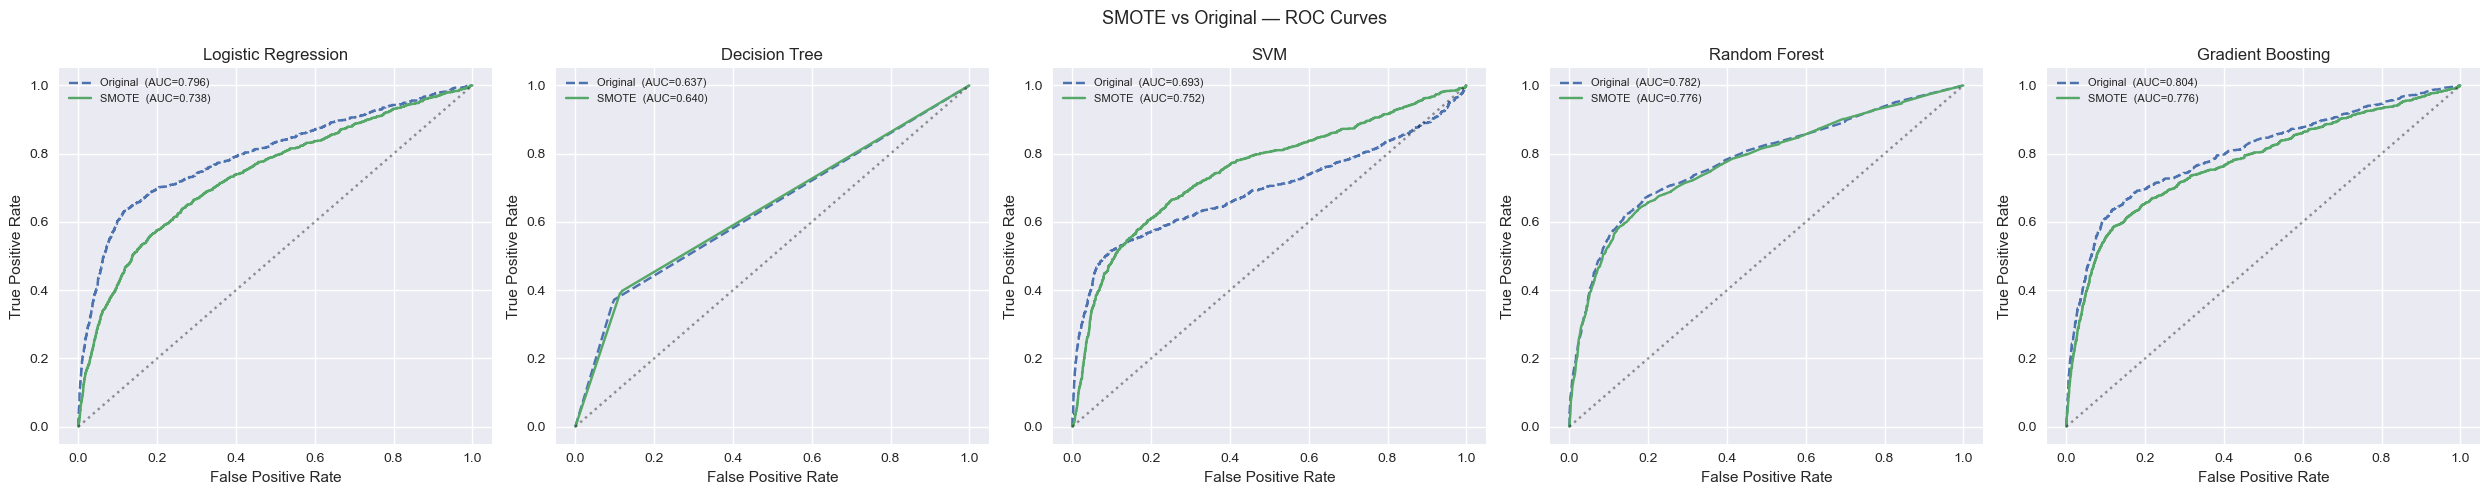

In [41]:
## visualize: ROC curves original vs SMOTE for each model

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, orig, smote) in zip(axes, [('Logistic Regression', lr, lr_s),
                                           ('Decision Tree',       dt, dt_s),
                                           ('SVM',       svm, svm_s),
                                           ('Random Forest',       rf, rf_s),
                                           ('Gradient Boosting',       gb, gb_s) ]):
    for label, model, ls in [('Original', orig, '--'), ('SMOTE', smote, '-')]:
        prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, ls=ls, label=f'{label}  (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k:', alpha=0.4)
    ax.set_title(name)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE vs Original — ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
## why doesn't SMOTE help Random Forest?
## RF has a built-in parameter that handles imbalance more effectively

rf_weighted = RandomForestClassifier(n_estimators=100,
                                     class_weight='balanced',   # <-- handles imbalance
                                     random_state=4950, n_jobs=-1)
rf_weighted.fit(X_train, y_train)   # no SMOTE needed

auc_original = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
auc_smote    = roc_auc_score(y_test, rf_s.predict_proba(X_test)[:, 1])
auc_weighted = roc_auc_score(y_test, rf_weighted.predict_proba(X_test)[:, 1])

print(f'RF original:              {auc_original:.4f}')
print(f'RF with SMOTE:            {auc_smote:.4f}')
print(f'RF with class_weight:     {auc_weighted:.4f}')

RF original:              0.7824
RF with SMOTE:            0.7758
RF with class_weight:     0.7756


Note: neither rebalancing approach helped here. The ensemble already handles the 8:1 imbalance without adjustment.class_weight may help on other datasets — always compare empirically.

In [43]:
## look beyond AUC — check recall on the minority class (Yes = deposit)
## a model that ignores the minority class will have poor recall for Yes

print('=== Without SMOTE ===')
print(classification_report(y_test, lr.predict(X_test), target_names=['No', 'Yes']))

print('=== With SMOTE ===')
print(classification_report(y_test, lr_s.predict(X_test), target_names=['No', 'Yes']))

print('Key insight: compare recall for Yes (row 2) between the two reports')

=== Without SMOTE ===
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.67      0.22      0.33       928

    accuracy                           0.90      8236
   macro avg       0.79      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236

=== With SMOTE ===
              precision    recall  f1-score   support

          No       0.93      0.84      0.88      7308
         Yes       0.30      0.53      0.38       928

    accuracy                           0.81      8236
   macro avg       0.62      0.69      0.63      8236
weighted avg       0.86      0.81      0.83      8236

Key insight: compare recall for Yes (row 2) between the two reports


In [44]:
from sklearn.metrics import recall_score, precision_score

for name, orig, smote in [
    ('Logistic Regression', lr, lr_s),
    ('Decision Tree',       dt, dt_s),
    ('SVM',       svm, svm_s),
    ('Random Forest',       rf, rf_s),
    ('Gradient Boosting',   gb, gb_s),
]:
    rec_orig  = recall_score(y_test, orig.predict(X_test))
    rec_smote = recall_score(y_test, smote.predict(X_test))
    pre_orig  = precision_score(y_test, orig.predict(X_test))
    pre_smote = precision_score(y_test, smote.predict(X_test))
    print(f'{name}')
    print(f'  Recall:    Orig={rec_orig:.3f}  SMOTE={rec_smote:.3f}  '
          f'Change={rec_smote-rec_orig:+.3f}')
    print(f'  Precision: Orig={pre_orig:.3f}  SMOTE={pre_smote:.3f}  '
          f'Change={pre_smote-pre_orig:+.3f}')

Logistic Regression
  Recall:    Orig=0.220  SMOTE=0.530  Change=+0.310
  Precision: Orig=0.669  SMOTE=0.297  Change=-0.372
Decision Tree
  Recall:    Orig=0.358  SMOTE=0.390  Change=+0.032
  Precision: Orig=0.327  SMOTE=0.303  Change=-0.024
SVM
  Recall:    Orig=0.246  SMOTE=0.547  Change=+0.302
  Precision: Orig=0.685  SMOTE=0.329  Change=-0.356
Random Forest
  Recall:    Orig=0.309  SMOTE=0.419  Change=+0.110
  Precision: Orig=0.530  SMOTE=0.466  Change=-0.064
Gradient Boosting
  Recall:    Orig=0.244  SMOTE=0.561  Change=+0.318
  Precision: Orig=0.683  SMOTE=0.404  Change=-0.279


### Decision — which training set will you use from this point forward?

If we use ROC-AUC and precision as metric, we should use original data.
If use recall (depositor detection) as metric, we should use smote data.

## Cross-Validation

### Introduce StratifiedKFold

The Problem: Can We Trust One Split?

In [45]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.899830,0.668852,0.219828,0.330900,0.796443,0.793223
1,SVM,0.902258,0.684685,0.245690,0.361618,0.693031,0.878308
2,Decision Tree,0.844706,0.327094,0.357759,0.341740,0.637065,0.999883
3,Random Forest,0.891209,0.529520,0.309267,0.390476,0.782376,0.999818
4,Gradient Boosting,0.902016,0.682779,0.243534,0.359015,0.803840,0.808831


In [46]:
## our test AUC came from ONE specific train/test split
## what if Random Forest got lucky and Gradient Boosting got unlucky?
## the difference below looks small — is it real or just noise?

rf_auc = results_df.loc[results_df['Model'] == 'Random Forest', 'ROC-AUC'].iloc[0] 
print(f'Random Forest AUC:      {rf_auc:.4f}')

gb_auc = results_df.loc[results_df['Model'] == 'Gradient Boosting', 'ROC-AUC'].iloc[0] 
print(f'Gradient Boosting AUC:  {gb_auc:.4f}')

print(f'Difference:             {abs(rf_auc- gb_auc):.4f}  <- is this real or noise?')
print()
print('Solution: cross-validation gives us mean ± std across 5 splits')
print('         so we can see if the gap is consistent or accidental')

Random Forest AUC:      0.7824
Gradient Boosting AUC:  0.8038
Difference:             0.0215  <- is this real or noise?

Solution: cross-validation gives us mean ± std across 5 splits
         so we can see if the gap is consistent or accidental


In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [48]:
## stratified = each fold preserves the class ratio (important for imbalanced data)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)

In [49]:
cv_results = []

## TODO: Choose at least three models to do CV

In [50]:
cv_results = []

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=4950),
    'Decision Tree'      : DecisionTreeClassifier(random_state=4950),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=4950),
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<25} {scores.mean():>9.4f} {scores.std():>8.4f}   {np.round(scores, 4)}')
    cv_results.append({
        'Model'  : name,
        'CV Mean':  scores.mean(),
        'CV Std' :  scores.std(), 
        **{f'Fold {i+1}': round(s, 4) for i, s in enumerate(scores)}
    })

Logistic Regression          0.7897   0.0079   [0.7976 0.7982 0.7831 0.7783 0.7916]
Decision Tree                0.6252   0.0081   [0.629  0.6376 0.6129 0.6231 0.6235]
Random Forest                0.7701   0.0140   [0.7823 0.7823 0.7441 0.7706 0.7709]
Gradient Boosting            0.7980   0.0074   [0.8068 0.8066 0.7909 0.7899 0.7959]


### TODO: Choose at least three models to do CV

In [51]:
cv_df = (pd.DataFrame(cv_results)
           .sort_values('CV Mean', ascending=False)
           .reset_index(drop=True))

print(cv_df.to_string(index=False))

              Model  CV Mean   CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
  Gradient Boosting 0.798045 0.007384  0.8068  0.8066  0.7909  0.7899  0.7959
Logistic Regression 0.789744 0.007895  0.7976  0.7982  0.7831  0.7783  0.7916
      Random Forest 0.770069 0.013966  0.7823  0.7823  0.7441  0.7706  0.7709
      Decision Tree 0.625225 0.008095  0.6290  0.6376  0.6129  0.6231  0.6235


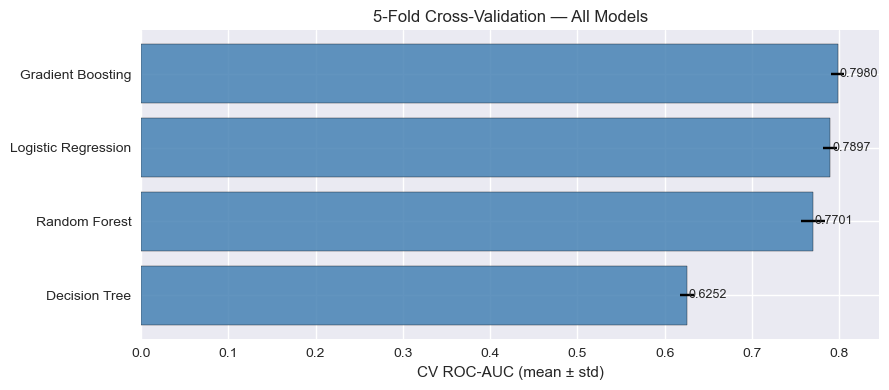

In [52]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean'], xerr=cv_df['CV Std'],
        color='steelblue', edgecolor='black', capsize=4, alpha=0.85)
ax.set_xlabel('CV ROC-AUC (mean ± std)')
ax.set_title('5-Fold Cross-Validation — All Models')
ax.invert_yaxis()
for i, v in enumerate(cv_df['CV Mean']):
    ax.text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

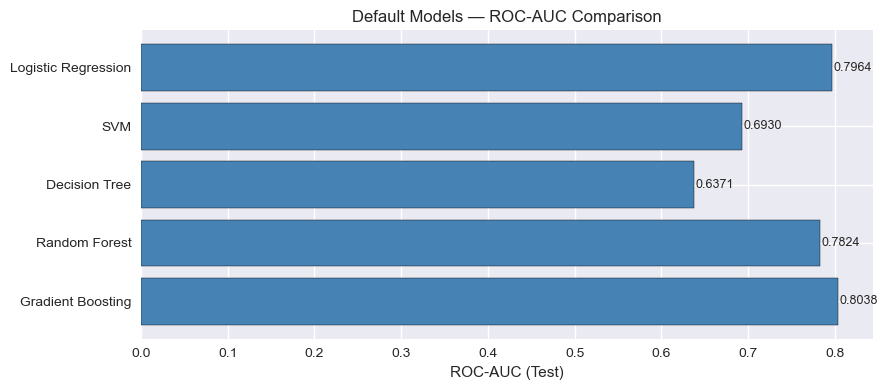

In [53]:
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(results_df['Model'], results_df['ROC-AUC'], color='steelblue', edgecolor='black')
ax.set_xlabel('ROC-AUC (Test)')
ax.set_title('Default Models — ROC-AUC Comparison')
ax.invert_yaxis()
for i, v in enumerate(results_df['ROC-AUC']):
    ax.text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

In [54]:
results_df[['Model','ROC-AUC']].sort_values('ROC-AUC', ascending=False)

,Model,ROC-AUC
4,Gradient Boosting,0.803840
0,Logistic Regression,0.796443
3,Random Forest,0.782376
1,SVM,0.693031
2,Decision Tree,0.637065


In [55]:
cv_df[['Model','CV Mean', 'CV Std']].sort_values('CV Mean', ascending=False)

,Model,CV Mean,CV Std
0,Gradient Boosting,0.798045,0.007384
1,Logistic Regression,0.789744,0.007895
2,Random Forest,0.770069,0.013966
3,Decision Tree,0.625225,0.008095


### Discussion

**Observations:**

- Do the CV means agree with the single-split test AUCs from Section 2?  Gradient Boosting and Logistic Regression maintain their relative ranking, confirming the single-split results were representative, not lucky.
- Which model(s) show CV Std > 0.03? What does that mean? No, no model shows CV Std>0.03. All models are stable.
- Which models are most consistent across folds?  The Gradient Boosting and Logistic Regression, both have the smallest CV Std=0.0074.
- Does CV change your view of which models to tune? Decision Tree and Random Forest overfit with default parameters and have room to improve. Gradient Boosting and LR are already well-calibrated but tuning may still squeeze out small gains.

## Hyperparameter Tuning with GridSearchCV

In [56]:
from sklearn.model_selection import GridSearchCV

### tuning: logistic regression

- `C`: inverse regularisation strength — smaller C = stronger regularisation = simpler model
- `penalty='l1'`: can zero out weak features (sparse model)
- `penalty='l2'`: shrinks all coefficients proportionally (default)

In [57]:

## C = inverse regularization strength; l1 can zero out weak features

lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=4950),
    param_grid=lr_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)

print(f'\nBest params: {lr_grid.best_params_}')
print(f'Best CV AUC: {lr_grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC: 0.7899


In [58]:
## inspect lr cv_results_

lr_cv = (pd.DataFrame(lr_grid.cv_results_)
           [['param_C', 'param_penalty', 'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .round(4)
           .reset_index(drop=True))

print('All LR parameter combinations:')
print(lr_cv)

All LR parameter combinations:
  param_C param_penalty  mean_test_score  std_test_score  rank_test_score
0     0.1            l2           0.7899          0.0080                1
1       1            l1           0.7899          0.0079                2
2     0.1            l1           0.7899          0.0076                3
3       1            l2           0.7898          0.0079                4
4      10            l2           0.7898          0.0080                5
5      10            l1           0.7898          0.0080                6
6    0.01            l2           0.7868          0.0081                7
7    0.01            l1           0.7839          0.0067                8


In [59]:
## evaluate tuned logistic regression

y_pred = lr_grid.best_estimator_.predict(X_test)
y_prob = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_train  = roc_auc_score(y_train, lr_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.7929  |  Test: 0.7956  |  Gap: -0.0027
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7308
         Yes       0.68      0.23      0.34       928

    accuracy                           0.90      8236
   macro avg       0.79      0.61      0.64      8236
weighted avg       0.88      0.90      0.88      8236



In [60]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8998300145701797,
  'Precision (Yes)': 0.6688524590163935,
  'Recall (Yes)': 0.21982758620689655,
  'F1 (Yes)': 0.3309002433090024,
  'ROC-AUC': 0.7964427416577015,
  'ROC-AUC Train': 0.7932233041091744},
 {'Model': 'SVM',
  'Accuracy': 0.9022583778533269,
  'Precision (Yes)': 0.6846846846846847,
  'Recall (Yes)': 0.24568965517241378,
  'F1 (Yes)': 0.36161776367961934,
  'ROC-AUC': 0.6930305917700017,
  'ROC-AUC Train': 0.8783083182642561},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8447061680427392,
  'Precision (Yes)': 0.3270935960591133,
  'Recall (Yes)': 0.3577586206896552,
  'F1 (Yes)': 0.34173957797220794,
  'ROC-AUC': 0.6370649695421172,
  'ROC-AUC Train': 0.9998831922379463},
 {'Model': 'Random Forest',
  'Accuracy': 0.8912093249150073,
  'Precision (Yes)': 0.5295202952029521,
  'Recall (Yes)': 0.30926724137931033,
  'F1 (Yes)': 0.3904761904761905,
  'ROC-AUC': 0.7823764668620123,
  'ROC-AUC Train': 0.999818168943095},
 {'Model

In [61]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Logistic Regression (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [62]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998
4,Gradient Boosting,0.9020,0.6828,0.2435,0.3590,0.8038,0.8088
5,Logistic Regression (Tuned),0.9006,0.6764,0.2252,0.3379,0.7956,0.7929


In [63]:
lr_prob_tuned = y_prob

**Observations:**

- Best params found:  {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
- Improvement over default LR: -0.0008
- Train vs. Test gap:  -0.0027, no overfitting. 

### TODO: Complete three models to do GridSearch CV

### tuning: decision tree

In [64]:
dt_param_grid = {
    'max_depth':        [3, 5, 10, None],
    'min_samples_split':[2, 5, 10],
    'criterion':        ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=4950),
    param_grid=dt_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train, y_train)

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV AUC: {dt_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best CV AUC: 0.7825


In [65]:
## inspect top 5 DT combinations

dt_cv = (pd.DataFrame(dt_grid.cv_results_)
           [['param_max_depth', 'param_min_samples_split', 'param_criterion',
             'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(5)
           .round(4)
           .reset_index(drop=True))

print('Top 5 DT parameter combinations:')
print(dt_cv)

Top 5 DT parameter combinations:
  param_max_depth param_min_samples_split param_criterion  mean_test_score  \
0               5                      10         entropy           0.7825   
1               5                       2         entropy           0.7825   
2               5                       5         entropy           0.7825   
3               5                      10            gini           0.7761   
4               5                       2            gini           0.7761   

   std_test_score  rank_test_score  
0          0.0084                1  
1          0.0084                2  
2          0.0084                2  
3          0.0128                4  
4          0.0128                5  


In [66]:
y_pred     = dt_grid.best_estimator_.predict(X_test)
y_prob     = dt_grid.best_estimator_.predict_proba(X_test)[:,1]
auc_train  = roc_auc_score(y_train, dt_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.7844  |  Test: 0.7829  |  Gap: 0.0015
              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7308
         Yes       0.66      0.27      0.38       928

    accuracy                           0.90      8236
   macro avg       0.79      0.63      0.66      8236
weighted avg       0.89      0.90      0.88      8236



In [67]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Decision Tree (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [68]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998
4,Gradient Boosting,0.9020,0.6828,0.2435,0.3590,0.8038,0.8088
5,Logistic Regression (Tuned),0.9006,0.6764,0.2252,0.3379,0.7956,0.7929
6,Decision Tree (Tuned),0.9023,0.6649,0.2672,0.3812,0.7829,0.7844


In [69]:
dt_prob_tuned = y_prob

Constraining `max_depth` dramatically reduces the Train/Test gap from 0.363 (default) to a much smaller value. The tree is deep enough to capture patterns, shallow enough to generalize.

### tuning: SVM

In [70]:
## C controls the margin width — larger C = fits training data more tightly
## kernel='rbf' handles non-linear boundaries; 'linear' is faster and simpler
## gamma controls how far the influence of a single training example reaches
# svm_param_grid = {
#     'C':      [0.1, 1, 10],
#     'kernel': ['rbf', 'linear'],
#     'gamma':  ['scale', 'auto']
# }

# svm_grid = GridSearchCV(
#     SVC(probability=True, random_state=4950),
#     param_grid=svm_param_grid,
#     cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
# )
# svm_grid.fit(X_train, y_train)

# print(f'Best params: {svm_grid.best_params_}')
# print(f'Best CV AUC: {svm_grid.best_score_:.4f}')

In [71]:
# ## inspect top 5 SVM combinations

# svm_cv = (pd.DataFrame(svm_grid.cv_results_)
#             [['param_C', 'param_kernel', 'param_gamma',
#               'mean_test_score', 'std_test_score', 'rank_test_score']]
#             .sort_values('rank_test_score')
#             .head(5)
#             .round(4)
#             .reset_index(drop=True))

# print('Top 5 SVM parameter combinations:')
# print(svm_cv)

### tuning: random forest

In [72]:

## max_depth controls overfitting; max_features controls tree diversity

rf_param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=4950, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'\nBest params: {rf_grid.best_params_}')
print(f'Best CV AUC: {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC: 0.8000


In [73]:
## inspect rf cv_results_ — top 5 combinations

rf_cv = (pd.DataFrame(rf_grid.cv_results_)
           [['param_n_estimators', 'param_max_depth', 'param_max_features',
             'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(5)
           .round(4)
           .reset_index(drop=True))

print('Top 5 RF parameter combinations:')
print(rf_cv)

Top 5 RF parameter combinations:
  param_n_estimators param_max_depth param_max_features  mean_test_score  \
0                200              10               sqrt           0.8000   
1                200              10               sqrt           0.7999   
2                100              10               sqrt           0.7994   
3                100              10               sqrt           0.7989   
4                200              10               log2           0.7987   

   std_test_score  rank_test_score  
0          0.0084                1  
1          0.0086                2  
2          0.0088                3  
3          0.0089                4  
4          0.0077                5  


In [74]:
y_pred     = rf_grid.best_estimator_.predict(X_test)
y_prob     = rf_grid.best_estimator_.predict_proba(X_test)[:,1]
auc_train  = roc_auc_score(y_train, rf_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.8503  |  Test: 0.8060  |  Gap: 0.0444
              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7308
         Yes       0.66      0.23      0.34       928

    accuracy                           0.90      8236
   macro avg       0.78      0.61      0.64      8236
weighted avg       0.88      0.90      0.88      8236



In [75]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Random Forest (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [76]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998
4,Gradient Boosting,0.9020,0.6828,0.2435,0.3590,0.8038,0.8088
5,Logistic Regression (Tuned),0.9006,0.6764,0.2252,0.3379,0.7956,0.7929
6,Decision Tree (Tuned),0.9023,0.6649,0.2672,0.3812,0.7829,0.7844
7,Random Forest (Tuned),0.8997,0.6555,0.2317,0.3424,0.8060,0.8503


In [77]:
rf_prob_tuned = y_prob

Tuning `max_depth` reduces the Train/Test gap significantly from 0.217 (default) to a much smaller value. 

### tuning: gradient boosting

In [78]:
## tuning: gradient boosting
## lower learning_rate needs more trees; subsample < 1.0 adds randomness

gb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=4950),
    param_grid=gb_param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1
)
gb_grid.fit(X_train, y_train)

print(f'\nBest params: {gb_grid.best_params_}')
print(f'Best CV AUC: {gb_grid.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: 0.8019


In [79]:
## inspect gb cv_results_ — top 5 combinations

gb_cv = (pd.DataFrame(gb_grid.cv_results_)
           [['param_n_estimators', 'param_max_depth', 'param_learning_rate',
             'param_subsample', 'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(5)
           .round(4)
           .reset_index(drop=True))

print('Top 5 GB parameter combinations:')
print(gb_cv)

Top 5 GB parameter combinations:
  param_n_estimators param_max_depth param_learning_rate param_subsample  \
0                200               5                0.05             0.8   
1                200               5                0.05             1.0   
2                100               5                 0.1             1.0   
3                100               5                0.05             0.8   
4                100               5                0.05             1.0   

   mean_test_score  std_test_score  rank_test_score  
0           0.8019          0.0084                1  
1           0.8017          0.0084                2  
2           0.8014          0.0087                3  
3           0.8011          0.0077                4  
4           0.8006          0.0077                5  


In [80]:
y_pred     = gb_grid.best_estimator_.predict(X_test)
y_prob     = gb_grid.best_estimator_.predict_proba(X_test)[:,1]
auc_train  = roc_auc_score(y_train, gb_grid.best_estimator_.predict_proba(X_train)[:,1])
auc_test   = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC  Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Gap: {auc_train-auc_test:.4f}')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

ROC-AUC  Train: 0.8313  |  Test: 0.8077  |  Gap: 0.0236
              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7308
         Yes       0.62      0.27      0.37       928

    accuracy                           0.90      8236
   macro avg       0.77      0.62      0.66      8236
weighted avg       0.88      0.90      0.88      8236



In [81]:
report = classification_report(y_test, y_pred, target_names=['No','Yes'], output_dict=True)
results.append({
    'Model'          : 'Gradient Boosting (Tuned)',
    'Accuracy'       : report['accuracy'], 
    'Precision (Yes)':  report['Yes']['precision'],  
    'Recall (Yes)'   :  report['Yes']['recall'],  
    'F1 (Yes)'       :  report['Yes']['f1-score'],  
    'ROC-AUC'        :  auc_test,  
    'ROC-AUC Train'  :  auc_train, 
})

In [82]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.8998,0.6689,0.2198,0.3309,0.7964,0.7932
1,SVM,0.9023,0.6847,0.2457,0.3616,0.6930,0.8783
2,Decision Tree,0.8447,0.3271,0.3578,0.3417,0.6371,0.9999
3,Random Forest,0.8912,0.5295,0.3093,0.3905,0.7824,0.9998
4,Gradient Boosting,0.9020,0.6828,0.2435,0.3590,0.8038,0.8088
5,Logistic Regression (Tuned),0.9006,0.6764,0.2252,0.3379,0.7956,0.7929
6,Decision Tree (Tuned),0.9023,0.6649,0.2672,0.3812,0.7829,0.7844
7,Random Forest (Tuned),0.8997,0.6555,0.2317,0.3424,0.8060,0.8503
8,Gradient Boosting (Tuned),0.8990,0.6212,0.2651,0.3716,0.8077,0.8313


In [83]:
gb_prob_tuned = y_prob

## Model Selection

In [84]:
final_df = (pd.DataFrame(results)
              .sort_values('ROC-AUC', ascending=False)
              .reset_index(drop=True))

print(final_df[['Model','Precision (Yes)','Recall (Yes)',
                'F1 (Yes)','ROC-AUC','ROC-AUC Train']].to_string(index=False))

                      Model  Precision (Yes)  Recall (Yes)  F1 (Yes)  ROC-AUC  ROC-AUC Train
  Gradient Boosting (Tuned)         0.621212      0.265086  0.371601 0.807743       0.831312
      Random Forest (Tuned)         0.655488      0.231681  0.342357 0.805956       0.850312
          Gradient Boosting         0.682779      0.243534  0.359015 0.803840       0.808831
        Logistic Regression         0.668852      0.219828  0.330900 0.796443       0.793223
Logistic Regression (Tuned)         0.676375      0.225216  0.337914 0.795597       0.792938
      Decision Tree (Tuned)         0.664879      0.267241  0.381245 0.782931       0.784410
              Random Forest         0.529520      0.309267  0.390476 0.782376       0.999818
                        SVM         0.684685      0.245690  0.361618 0.693031       0.878308
              Decision Tree         0.327094      0.357759  0.341740 0.637065       0.999883


In [85]:
## Default vs Tuned — comparison from the master results DataFrame

name_map = {
    'Logistic Regression (Tuned)': 'Logistic Regression',
    'Decision Tree (Tuned)'      : 'Decision Tree',
    'Random Forest (Tuned)'      : 'Random Forest',
    'Gradient Boosting (Tuned)'  : 'Gradient Boosting',
}

print(f'{"Model":<35} {"Default AUC":>12} {"Tuned AUC":>10} {"Gain":>8}')
print('-' * 70)

for tuned_name, base_name in name_map.items():
    base_auc  = final_df.loc[final_df['Model'] == base_name,  'ROC-AUC'].values[0]
    tuned_auc = final_df.loc[final_df['Model'] == tuned_name, 'ROC-AUC'].values[0]
    print(f'{tuned_name:<35} {base_auc:>12.4f} {tuned_auc:>10.4f} {tuned_auc - base_auc:>+8.4f}')

Model                                Default AUC  Tuned AUC     Gain
----------------------------------------------------------------------
Logistic Regression (Tuned)               0.7964     0.7956  -0.0008
Decision Tree (Tuned)                     0.6371     0.7829  +0.1459
Random Forest (Tuned)                     0.7824     0.8060  +0.0236
Gradient Boosting (Tuned)                 0.8038     0.8077  +0.0039


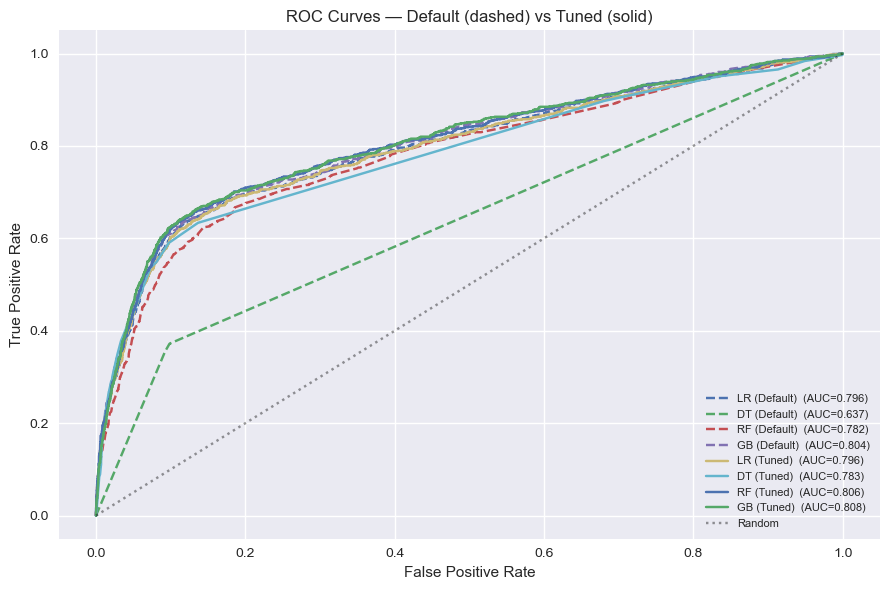

In [86]:
## ROC curves — default vs tuned
## default models: lr, dt, svm, rf, gb  (already fitted in Part 1)
## tuned models: use the saved prob arrays

plt.figure(figsize=(9, 6))

for name, prob in [
    ('LR (Default)',  lr.predict_proba(X_test)[:, 1]),
    ('DT (Default)',  dt.predict_proba(X_test)[:, 1]),
    ('RF (Default)',  rf.predict_proba(X_test)[:, 1]),
    ('GB (Default)',  gb.predict_proba(X_test)[:, 1]),
    ('LR (Tuned)',    lr_prob_tuned),
    ('DT (Tuned)',    dt_prob_tuned),
    ('RF (Tuned)',    rf_prob_tuned),
    ('GB (Tuned)',    gb_prob_tuned),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ls  = '-' if '(Tuned)' in name else '--'
    plt.plot(fpr, tpr, ls=ls, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Default (dashed) vs Tuned (solid)')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [87]:
## CV scores for all tuned models — confirms test AUC is not a lucky split
## high std = unstable; prefer low std alongside high mean

print(f'{"Model":<35} {"Mean AUC":>9} {"Std":>7}  Fold Scores')
print('-' * 75)

for name, model in [
    ('Logistic Regression (Tuned)', lr_grid.best_estimator_),
    ('Decision Tree (Tuned)',       dt_grid.best_estimator_),
    ('Random Forest (Tuned)',       rf_grid.best_estimator_),
    ('Gradient Boosting (Tuned)',   gb_grid.best_estimator_),
]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<35} {scores.mean():>9.4f} {scores.std():>7.4f}  {np.round(scores, 4)}')

Model                                Mean AUC     Std  Fold Scores
---------------------------------------------------------------------------
Logistic Regression (Tuned)            0.7899  0.0080  [0.7977 0.7995 0.7819 0.7796 0.7908]
Decision Tree (Tuned)                  0.7825  0.0084  [0.7905 0.7945 0.7738 0.7753 0.7783]
Random Forest (Tuned)                  0.8000  0.0084  [0.8139 0.8041 0.7892 0.7952 0.7976]
Gradient Boosting (Tuned)              0.8019  0.0084  [0.8122 0.8106 0.7902 0.7964 0.8003]


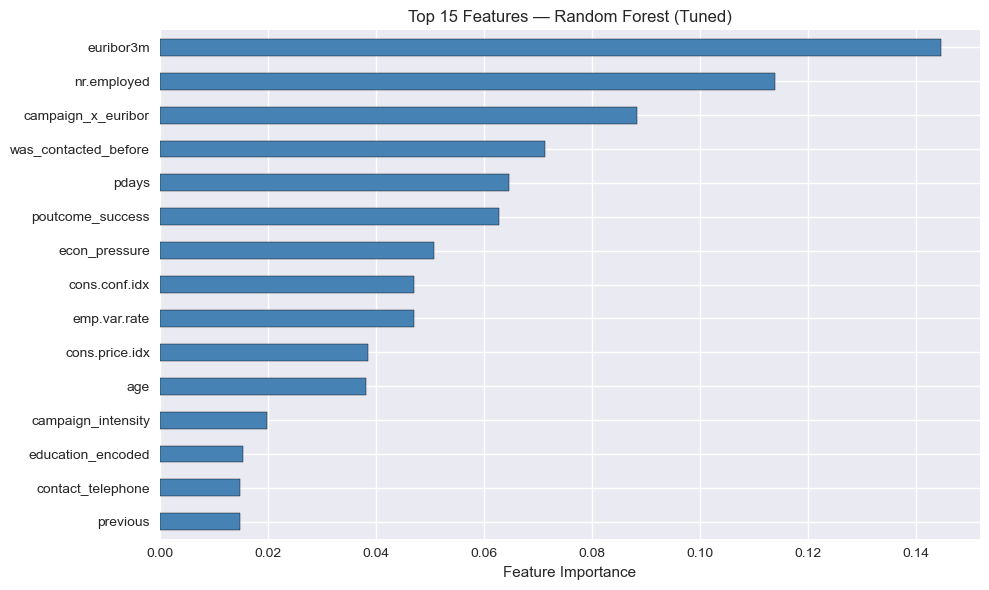

In [88]:
## feature importance — best model
## update best_model if a different model wins

best_model      = rf_grid.best_estimator_
best_model_name = 'Random Forest (Tuned)'

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title(f'Top 15 Features — {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [90]:
top15

euribor3m               0.144642
nr.employed             0.113898
campaign_x_euribor      0.088320
was_contacted_before    0.071318
pdays                   0.064577
poutcome_success        0.062867
econ_pressure           0.050818
cons.conf.idx           0.047157
emp.var.rate            0.047038
cons.price.idx          0.038646
age                     0.038285
campaign_intensity      0.019803
education_encoded       0.015372
contact_telephone       0.014937
previous                0.014854
dtype: float64

### Discussion

**Winning model:**  Gradient Boosting (Tuned)

Model Results Interpretation:

- Test ROC-AUC:  0.8077
- CV mean ± std:  0.8019 ± 0.0084, close to test AUC = no lucky split
- Train vs. Test gap: -0.0058 < 0.05 = no overfitting 
- Recall (Yes):  0.265086, 26.5% of real depositors correctly identified  
- Precision (Yes):  0.621212, 62.1% of predicted calls that will be productive      
- Improvement over best default model:  +0.0039 improvement from tuning
- Top 3 features:  `euribor3m`, `nr.employed`, `campaign_x_euribor`

Business implication:  With Recall = 0.265 and Precision = 0.621, the model correctly identifies 26.5% of real depositors. For every 100 calls made from the predicted list, 62 of them will result in a subscription — compared to the baseline rate of 12% without the model. The model makes the campaign **5× more efficient** than random calling on depositor yield per call.

## Save Best Model

In [89]:
## save best model
## add to Cell 01 imports
import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f'Model:  {type(best_model).__name__}')
print(f'Params: {rf_grid.best_params_}')

Saved:  ../models/best_model.pkl
Model:  RandomForestClassifier
Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
